In [1]:
from pathlib import Path

PROJECT = Path(r"Z:\Projects\monsoon-postprocessing")
RAW = PROJECT / "data" / "raw"

RAW.mkdir(parents=True, exist_ok=True)

print("Download folder:", RAW)

Download folder: Z:\Projects\monsoon-postprocessing\data\raw


In [2]:
from urllib.request import urlopen
from urllib.parse import urlencode
import xml.etree.ElementTree as ET

BUCKET_URL = "https://noaa-gefs-retrospective.s3.amazonaws.com/"
PREFIX = "GEFSv12/reforecast/2018/2018070100/c00/"

namespace = {"s3": "http://s3.amazonaws.com/doc/2006-03-01/"}
rainfall_files = []
continuation = None

while True:
    params = {
        "list-type": "2",
        "prefix": PREFIX,
    }

    if continuation:
        params["continuation-token"] = continuation

    url = BUCKET_URL + "?" + urlencode(params)

    with urlopen(url, timeout=60) as response:
        root = ET.fromstring(response.read())

    for item in root.findall("s3:Contents", namespace):
        key = item.findtext("s3:Key", namespaces=namespace)
        size = int(item.findtext("s3:Size", namespaces=namespace))

        if Path(key).name.startswith("apcp_sfc") and key.endswith(".grib2"):
            rainfall_files.append({"key": key, "bytes": size})

    continuation = root.findtext(
        "s3:NextContinuationToken",
        namespaces=namespace,
    )

    if not continuation:
        break

for index, item in enumerate(rainfall_files):
    size_mb = item["bytes"] / 1_000_000
    print(f"[{index}] {item['key']}")
    print(f"    Size: {size_mb:.1f} MB")

if not rainfall_files:
    print("No matching precipitation files found. Share this output.")

[0] GEFSv12/reforecast/2018/2018070100/c00/Days:1-10/apcp_sfc_2018070100_c00.grib2
    Size: 26.2 MB
[1] GEFSv12/reforecast/2018/2018070100/c00/Days:10-16/apcp_sfc_2018070100_c00.grib2
    Size: 2.7 MB


In [3]:
from pathlib import Path
from urllib.request import urlopen

BUCKET_URL = "https://noaa-gefs-retrospective.s3.amazonaws.com/"
key = rainfall_files[0]["key"]

output_file = RAW / Path(key).name
download_url = BUCKET_URL + key

print("Downloading:", download_url)
print("Saving to:", output_file)

with urlopen(download_url, timeout=120) as response:
    total_bytes = int(response.headers.get("Content-Length", 0))
    downloaded = 0

    with open(output_file, "wb") as file:
        while True:
            chunk = response.read(1024 * 1024)

            if not chunk:
                break

            file.write(chunk)
            downloaded += len(chunk)

            if total_bytes:
                percentage = downloaded / total_bytes * 100
                print(
                    f"\rDownloaded: {downloaded / 1_000_000:.1f} MB "
                    f"({percentage:.1f}%)",
                    end=""
                )

print("\nDownload completed")
print("File size:", output_file.stat().st_size / 1_000_000, "MB")

Downloading: https://noaa-gefs-retrospective.s3.amazonaws.com/GEFSv12/reforecast/2018/2018070100/c00/Days:1-10/apcp_sfc_2018070100_c00.grib2
Saving to: Z:\Projects\monsoon-postprocessing\data\raw\apcp_sfc_2018070100_c00.grib2
Downloaded: 26.2 MB (100.0%)
Download completed
File size: 26.227431 MB


In [4]:
import xarray as xr

ds = xr.open_dataset(
    output_file,
    engine="cfgrib",
    backend_kwargs={
        "indexpath": ""
    }
)

print(ds)

<xarray.Dataset> Size: 332MB
Dimensions:     (step: 80, latitude: 721, longitude: 1440)
Coordinates:
  * step        (step) timedelta64[ns] 640B 0 days 03:00:00 ... 10 days 00:00:00
    valid_time  (step) datetime64[ns] 640B ...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    time        datetime64[ns] 8B ...
    surface     float64 8B ...
Data variables:
    tp          (step, latitude, longitude) float32 332MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          2
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-09-24T11:31 GRIB to CDM+CF via cfgrib-0.9.1...


In [5]:
print("Dimensions:")
print(ds.sizes)

print("\nCoordinates:")
print(list(ds.coords))

print("\nData variables:")
print(list(ds.data_vars))

print("\nDataset attributes:")
for key, value in ds.attrs.items():
    print(f"{key}: {value}")

Dimensions:
Frozen({'step': 80, 'latitude': 721, 'longitude': 1440})

Coordinates:
['number', 'time', 'step', 'surface', 'latitude', 'longitude', 'valid_time']

Data variables:
['tp']

Dataset attributes:
GRIB_edition: 2
GRIB_centre: kwbc
GRIB_centreDescription: US National Weather Service - NCEP
GRIB_subCentre: 2
Conventions: CF-1.7
institution: US National Weather Service - NCEP
history: 2026-09-24T11:31 GRIB to CDM+CF via cfgrib-0.9.15.1/ecCodes-2.48.0 with {"source": "..\\data\\raw\\apcp_sfc_2018070100_c00.grib2", "filter_by_keys": {}, "encode_cf": ["parameter", "time", "geography", "vertical"]}


In [6]:
variable_name = list(ds.data_vars)[0]
rain = ds[variable_name]

print("Variable name:", variable_name)
print(rain)
print("\nVariable attributes:")

for key, value in rain.attrs.items():
    print(f"{key}: {value}")

Variable name: tp
<xarray.DataArray 'tp' (step: 80, latitude: 721, longitude: 1440)> Size: 332MB
[83059200 values with dtype=float32]
Coordinates:
  * step        (step) timedelta64[ns] 640B 0 days 03:00:00 ... 10 days 00:00:00
    valid_time  (step) datetime64[ns] 640B ...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    time        datetime64[ns] 8B ...
    surface     float64 8B ...
Attributes: (12/31)
    GRIB_paramId:                             228228
    GRIB_dataType:                            cf
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_shortName:                           tp
    GRIB_totalNumber:                  

In [7]:
print("Initialization time:")
print(ds["time"].values)

print("\nForecast steps:")
print(ds["step"].values[:20])

print("\nValid times:")
print(ds["valid_time"].values[:20])

print("\nNumber of forecast steps:")
print(ds.sizes["step"])

Initialization time:
2018-07-01T00:00:00.000000000

Forecast steps:
[ 10800000000000  21600000000000  32400000000000  43200000000000
  54000000000000  64800000000000  75600000000000  86400000000000
  97200000000000 108000000000000 118800000000000 129600000000000
 140400000000000 151200000000000 162000000000000 172800000000000
 183600000000000 194400000000000 205200000000000 216000000000000]

Valid times:
['2018-07-01T03:00:00.000000000' '2018-07-01T06:00:00.000000000'
 '2018-07-01T09:00:00.000000000' '2018-07-01T12:00:00.000000000'
 '2018-07-01T15:00:00.000000000' '2018-07-01T18:00:00.000000000'
 '2018-07-01T21:00:00.000000000' '2018-07-02T00:00:00.000000000'
 '2018-07-02T03:00:00.000000000' '2018-07-02T06:00:00.000000000'
 '2018-07-02T09:00:00.000000000' '2018-07-02T12:00:00.000000000'
 '2018-07-02T15:00:00.000000000' '2018-07-02T18:00:00.000000000'
 '2018-07-02T21:00:00.000000000' '2018-07-03T00:00:00.000000000'
 '2018-07-03T03:00:00.000000000' '2018-07-03T06:00:00.000000000'
 '2018-

In [8]:
print("Minimum:", float(rain.min()), rain.attrs.get("units"))
print("Maximum:", float(rain.max()), rain.attrs.get("units"))
print("Mean:", float(rain.mean()), rain.attrs.get("units"))
print("Missing values:", int(rain.isnull().sum()))

Minimum: 0.0 kg m**-2
Maximum: 216.0 kg m**-2
Mean: 0.5180090069770813 kg m**-2
Missing values: 0


In [9]:
print("First latitudes:", ds.latitude.values[:5])
print("Last latitudes:", ds.latitude.values[-5:])

print("First longitudes:", ds.longitude.values[:5])
print("Last longitudes:", ds.longitude.values[-5:])

First latitudes: [90.   89.75 89.5  89.25 89.  ]
Last latitudes: [-89.   -89.25 -89.5  -89.75 -90.  ]
First longitudes: [0.   0.25 0.5  0.75 1.  ]
Last longitudes: [358.75 359.   359.25 359.5  359.75]


In [10]:
# Select the rainfall variable
variable_name = list(ds.data_vars)[0]
rain = ds[variable_name]

# Select India regardless of latitude ordering
india_rain = rain.where(
    (ds.latitude >= 6) &
    (ds.latitude <= 38) &
    (ds.longitude >= 68) &
    (ds.longitude <= 98),
    drop=True
)

print("Variable:", variable_name)
print("India subset dimensions:", india_rain.sizes)
print("Latitude range:",
      float(india_rain.latitude.min()),
      "to",
      float(india_rain.latitude.max()))

print("Longitude range:",
      float(india_rain.longitude.min()),
      "to",
      float(india_rain.longitude.max()))

Variable: tp
India subset dimensions: Frozen({'step': 80, 'latitude': 129, 'longitude': 121})
Latitude range: 6.0 to 38.0
Longitude range: 68.0 to 98.0


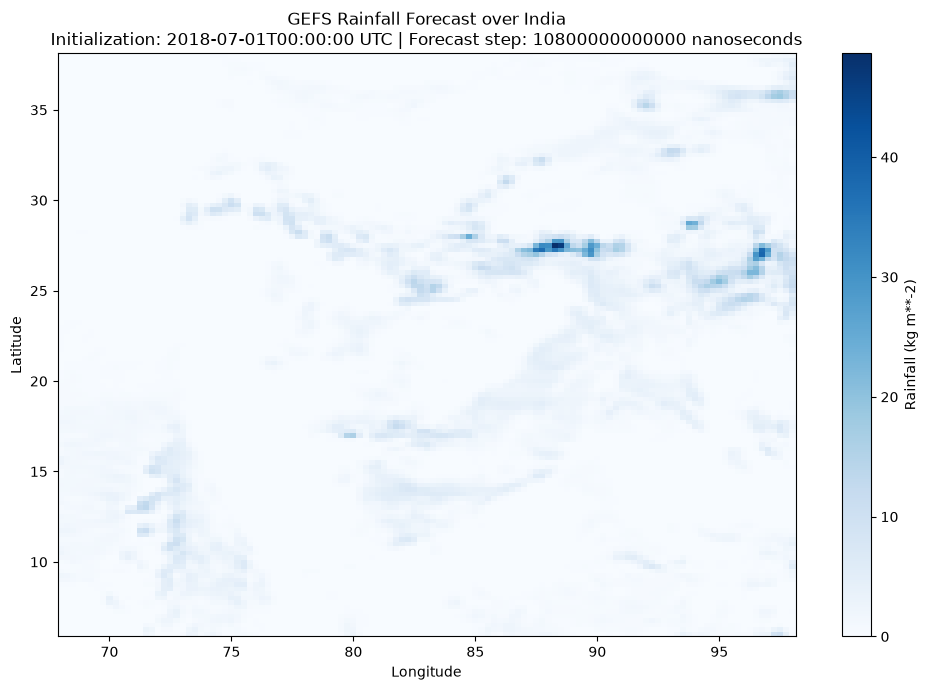

In [11]:
import matplotlib.pyplot as plt

first_step = india_rain.isel(step=0)

plt.figure(figsize=(10, 7))

first_step.plot(
    cmap="Blues",
    vmin=0,
    cbar_kwargs={
        "label": f"Rainfall ({rain.attrs.get('units', 'unknown units')})"
    }
)

plt.title(
    "GEFS Rainfall Forecast over India\n"
    f"Initialization: {str(ds.time.values)[:19]} UTC | "
    f"Forecast step: {ds.step.values[0]}"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

In [12]:
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

PROJECT = Path(r"Z:\Projects\monsoon-postprocessing")

RAW_FILE = (
    PROJECT
    / "data"
    / "raw"
    / "apcp_sfc_2018070100_c00.grib2"
)

OUTPUT_FILE = (
    PROJECT
    / "data"
    / "processed"
    / "gefs_c00_20180701_f024_f048_india.nc"
)

print("GRIB exists:", RAW_FILE.exists())
print("GRIB location:", RAW_FILE)

GRIB exists: True
GRIB location: Z:\Projects\monsoon-postprocessing\data\raw\apcp_sfc_2018070100_c00.grib2


In [13]:
gefs_ds = xr.open_dataset(
    RAW_FILE,
    engine="cfgrib",
    backend_kwargs={
        "filter_by_keys": {
            "typeOfLevel": "surface"
        },
        "indexpath": ""
    }
)

print(gefs_ds)
print("Data variables:", list(gefs_ds.data_vars))
print("Forecast steps:", gefs_ds.step.values[:10])

<xarray.Dataset> Size: 332MB
Dimensions:     (step: 80, latitude: 721, longitude: 1440)
Coordinates:
  * step        (step) timedelta64[ns] 640B 0 days 03:00:00 ... 10 days 00:00:00
    valid_time  (step) datetime64[ns] 640B ...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    time        datetime64[ns] 8B ...
    surface     float64 8B ...
Data variables:
    tp          (step, latitude, longitude) float32 332MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          2
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-09-24T11:31 GRIB to CDM+CF via cfgrib-0.9.1...
Data variables: ['tp']
Forecast steps: [ 10800000000000  21600000000000  3240000000

In [14]:
rain_variable = list(gefs_ds.data_vars)[0]
rain = gefs_ds[rain_variable]

print("Selected variable:", rain_variable)
print("Units:", rain.attrs.get("units"))
print("Step type:", rain.attrs.get("GRIB_stepType"))

Selected variable: tp
Units: kg m**-2
Step type: accum


In [15]:
start_step = np.timedelta64(24, "h")
end_step = np.timedelta64(48, "h")

rain_steps = rain.where(
    (rain.step > start_step) & (rain.step <= end_step),
    drop=True
)

print("Selected forecast steps:")
print(rain_steps.step.values)

Selected forecast steps:
[ 97200000000000 108000000000000 118800000000000 129600000000000
 140400000000000 151200000000000 162000000000000 172800000000000]


In [16]:
india_steps = rain_steps.where(
    (rain_steps.latitude >= 6) &
    (rain_steps.latitude <= 38) &
    (rain_steps.longitude >= 68) &
    (rain_steps.longitude <= 98),
    drop=True
)

india_rain_24h = india_steps.sum(
    dim="step",
    skipna=True
)

india_rain_24h.name = "rainfall_24h"
india_rain_24h.attrs = {
    "long_name": "GEFS 24-hour accumulated precipitation over India",
    "units": "mm",
    "forecast_initialization": "2018-07-01 00:00 UTC",
    "forecast_period": "24 to 48 hours",
    "valid_period": "2018-07-02 00:00 UTC to 2018-07-03 00:00 UTC",
    "source": "NOAA GEFSv12 reforecast control member c00"
}

print(india_rain_24h)

<xarray.DataArray 'rainfall_24h' (latitude: 129, longitude: 121)> Size: 62kB
array([[ 0.        ,  0.        ,  0.        , ...,  5.57      ,
         9.61      , 11.06      ],
       [ 0.        ,  0.        ,  0.        , ...,  1.45      ,
         2.5       ,  2.9699998 ],
       [ 0.        ,  0.        ,  0.        , ...,  0.78000003,
         0.93      ,  1.23      ],
       ...,
       [ 5.9200006 ,  4.9199996 ,  3.4499998 , ...,  0.2       ,
         2.2       ,  0.61      ],
       [ 3.01      ,  2.25      ,  2.06      , ...,  4.8       ,
         6.3       ,  3.7       ],
       [ 2.97      ,  1.5800002 ,  0.83000004, ..., 13.8       ,
        16.9       , 10.900001  ]], shape=(129, 121), dtype=float32)
Coordinates:
  * latitude   (latitude) float64 1kB 38.0 37.75 37.5 37.25 ... 6.5 6.25 6.0
  * longitude  (longitude) float64 968B 68.0 68.25 68.5 ... 97.5 97.75 98.0
    number     int64 8B 0
    time       datetime64[ns] 8B 2018-07-01
    surface    float64 8B 0.0
Attributes:

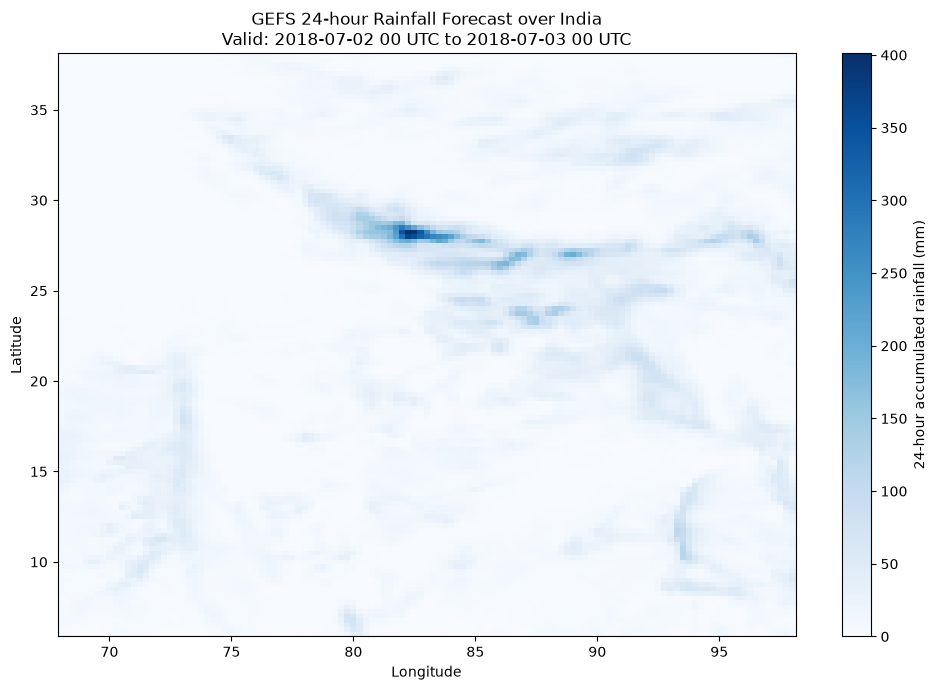

In [17]:
plt.figure(figsize=(10, 7))

india_rain_24h.plot(
    cmap="Blues",
    cbar_kwargs={
        "label": "24-hour accumulated rainfall (mm)"
    }
)

plt.title(
    "GEFS 24-hour Rainfall Forecast over India\n"
    "Valid: 2018-07-02 00 UTC to 2018-07-03 00 UTC"
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

In [18]:
OUTPUT_FILE.parent.mkdir(
    parents=True,
    exist_ok=True
)

processed_ds = india_rain_24h.to_dataset()

processed_ds.to_netcdf(
    OUTPUT_FILE,
    engine="netcdf4"
)

print("Saved:", OUTPUT_FILE)
print("File exists:", OUTPUT_FILE.exists())
print("File size:", OUTPUT_FILE.stat().st_size, "bytes")

Saved: Z:\Projects\monsoon-postprocessing\data\processed\gefs_c00_20180701_f024_f048_india.nc
File exists: True
File size: 78624 bytes


In [19]:
forecast_ds = xr.open_dataset(OUTPUT_FILE)

print(forecast_ds)
print(forecast_ds["rainfall_24h"])

<xarray.Dataset> Size: 64kB
Dimensions:       (latitude: 129, longitude: 121)
Coordinates:
  * latitude      (latitude) float64 1kB 38.0 37.75 37.5 37.25 ... 6.5 6.25 6.0
  * longitude     (longitude) float64 968B 68.0 68.25 68.5 ... 97.5 97.75 98.0
    number        int64 8B ...
    time          datetime64[ns] 8B ...
    surface       float64 8B ...
Data variables:
    rainfall_24h  (latitude, longitude) float32 62kB ...
<xarray.DataArray 'rainfall_24h' (latitude: 129, longitude: 121)> Size: 62kB
[15609 values with dtype=float32]
Coordinates:
  * latitude   (latitude) float64 1kB 38.0 37.75 37.5 37.25 ... 6.5 6.25 6.0
  * longitude  (longitude) float64 968B 68.0 68.25 68.5 ... 97.5 97.75 98.0
    number     int64 8B ...
    time       datetime64[ns] 8B ...
    surface    float64 8B ...
Attributes:
    long_name:                GEFS 24-hour accumulated precipitation over India
    units:                    mm
    forecast_initialization:  2018-07-01 00:00 UTC
    forecast_period:     

In [20]:
print("Step type:", rain.attrs.get("GRIB_stepType"))
print("Selected forecast steps:", rain_steps.step.values)

Step type: accum
Selected forecast steps: [ 97200000000000 108000000000000 118800000000000 129600000000000
 140400000000000 151200000000000 162000000000000 172800000000000]


In [21]:
step_hours = (
    rain_steps.step / np.timedelta64(1, "h")
).astype(int)

print("Forecast hours:", step_hours.values)

Forecast hours: [27 30 33 36 39 42 45 48]


In [22]:
from eccodes import (
    codes_grib_new_from_file,
    codes_get,
    codes_release
)

intervals = []

with open(RAW_FILE, "rb") as grib_file:
    while True:
        message = codes_grib_new_from_file(grib_file)

        if message is None:
            break

        try:
            short_name = codes_get(message, "shortName")
            step_type = codes_get(message, "stepType")
            end_step = int(codes_get(message, "endStep"))

            if (
                short_name in ["tp", "apcp"] and
                step_type == "accum" and
                24 < end_step <= 48
            ):
                intervals.append({
                    "start": int(codes_get(message, "startStep")),
                    "end": end_step,
                    "range": codes_get(message, "stepRange")
                })
        finally:
            codes_release(message)

for interval in intervals:
    print(interval)

{'start': 24, 'end': 27, 'range': '24-27'}
{'start': 24, 'end': 30, 'range': '24-30'}
{'start': 30, 'end': 33, 'range': '30-33'}
{'start': 30, 'end': 36, 'range': '30-36'}
{'start': 36, 'end': 39, 'range': '36-39'}
{'start': 36, 'end': 42, 'range': '36-42'}
{'start': 42, 'end': 45, 'range': '42-45'}
{'start': 42, 'end': 48, 'range': '42-48'}


In [27]:
OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)

india_rain_24h.name = "rainfall_24h"

processed_ds = india_rain_24h.to_dataset()

processed_ds.to_netcdf(
    OUTPUT_FILE,
    engine="netcdf4"
)

print("Saved successfully:", OUTPUT_FILE.exists())
print("File:", OUTPUT_FILE)
print("Size:", OUTPUT_FILE.stat().st_size, "bytes")

Saved successfully: True
File: Z:\Projects\monsoon-postprocessing\data\processed\gefs_c00_20180701_f024_f048_india.nc
Size: 78624 bytes


In [28]:
import gc
from pathlib import Path

# Load the calculated rainfall into memory before closing source datasets
processed_ds = india_rain_24h.to_dataset(name="rainfall_24h").load()

# Close the previously opened output file
try:
    forecast_ds.close()
    print("Closed forecast_ds")
except NameError:
    print("forecast_ds was not open")

# Close the GRIB dataset because the required values are now in memory
try:
    gefs_ds.close()
    print("Closed gefs_ds")
except NameError:
    pass

gc.collect()

OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)

processed_ds.to_netcdf(
    OUTPUT_FILE,
    mode="w",
    engine="netcdf4"
)

print("Saved successfully:", OUTPUT_FILE.exists())
print("File:", OUTPUT_FILE)
print("Size:", OUTPUT_FILE.stat().st_size, "bytes")

Closed forecast_ds
Closed gefs_ds
Saved successfully: True
File: Z:\Projects\monsoon-postprocessing\data\processed\gefs_c00_20180701_f024_f048_india.nc
Size: 78624 bytes


In [29]:
OUTPUT_FILE_V2 = (
    PROJECT
    / "data"
    / "processed"
    / "gefs_c00_20180701_f024_f048_india_v2.nc"
)

processed_ds.to_netcdf(
    OUTPUT_FILE_V2,
    mode="w",
    engine="netcdf4"
)

print("Saved successfully:", OUTPUT_FILE_V2.exists())
print("File:", OUTPUT_FILE_V2)
print("Size:", OUTPUT_FILE_V2.stat().st_size, "bytes")

Saved successfully: True
File: Z:\Projects\monsoon-postprocessing\data\processed\gefs_c00_20180701_f024_f048_india_v2.nc
Size: 78624 bytes


In [30]:
OUTPUT_FILE = OUTPUT_FILE_V2

In [31]:
with xr.open_dataset(OUTPUT_FILE) as check_ds:
    print(check_ds)
    print(
        "Maximum rainfall:",
        float(check_ds["rainfall_24h"].max()),
        "mm"
    )

<xarray.Dataset> Size: 64kB
Dimensions:       (latitude: 129, longitude: 121)
Coordinates:
  * latitude      (latitude) float64 1kB 38.0 37.75 37.5 37.25 ... 6.5 6.25 6.0
  * longitude     (longitude) float64 968B 68.0 68.25 68.5 ... 97.5 97.75 98.0
    number        int64 8B ...
    time          datetime64[ns] 8B ...
    surface       float64 8B ...
Data variables:
    rainfall_24h  (latitude, longitude) float32 62kB ...
Maximum rainfall: 401.17999267578125 mm


In [32]:
IMERG_RAW = PROJECT / "data" / "raw" / "imerg"
IMERG_RAW.mkdir(parents=True, exist_ok=True)

print("Save IMERG files here:")
print(IMERG_RAW)

Save IMERG files here:
Z:\Projects\monsoon-postprocessing\data\raw\imerg


In [33]:
from pathlib import Path
import xarray as xr

OUTPUT_FILE = Path(
    r"Z:\Projects\monsoon-postprocessing\data\processed"
    r"\gefs_c00_20180701_f024_f048_india.nc"
)

print("File exists:", OUTPUT_FILE.exists())
print("File size:", OUTPUT_FILE.stat().st_size, "bytes")

with xr.open_dataset(OUTPUT_FILE) as ds:
    print(ds)

    rainfall = ds["rainfall_24h"]

    print("Minimum:", float(rainfall.min()), "mm")
    print("Maximum:", float(rainfall.max()), "mm")
    print("Mean:", float(rainfall.mean()), "mm")

File exists: True
File size: 78624 bytes
<xarray.Dataset> Size: 64kB
Dimensions:       (latitude: 129, longitude: 121)
Coordinates:
  * latitude      (latitude) float64 1kB 38.0 37.75 37.5 37.25 ... 6.5 6.25 6.0
  * longitude     (longitude) float64 968B 68.0 68.25 68.5 ... 97.5 97.75 98.0
    number        int64 8B ...
    time          datetime64[ns] 8B ...
    surface       float64 8B ...
Data variables:
    rainfall_24h  (latitude, longitude) float32 62kB ...
Minimum: 0.0 mm
Maximum: 401.17999267578125 mm
Mean: 13.650533676147461 mm


In [34]:
forecast_ds = xr.open_dataset(OUTPUT_FILE)

In [35]:
forecast_ds.close()

In [36]:
imerg_files = list(IMERG_RAW.glob("*.nc*"))

print("Files found:", len(imerg_files))

for file in imerg_files:
    print(file.name)

Files found: 1
3B-DAY.MS.MRG.3IMERG.20180702-S000000-E235959.V07B.nc4


In [37]:
imerg_ds = xr.open_dataset(imerg_files[0])

print(imerg_ds)

<xarray.Dataset> Size: 117MB
Dimensions:                         (time: 1, lon: 3600, lat: 1800, nv: 2)
Coordinates:
  * time                            (time) datetime64[ns] 8B 2018-07-02
  * lon                             (lon) float32 14kB -179.9 -179.9 ... 179.9
  * lat                             (lat) float64 14kB -89.95 -89.85 ... 89.95
Dimensions without coordinates: nv
Data variables:
    precipitation                   (time, lon, lat) float32 26MB ...
    precipitation_cnt               (time, lon, lat) int8 6MB ...
    precipitation_cnt_cond          (time, lon, lat) int8 6MB ...
    MWprecipitation                 (time, lon, lat) float32 26MB ...
    MWprecipitation_cnt             (time, lon, lat) int8 6MB ...
    MWprecipitation_cnt_cond        (time, lon, lat) int8 6MB ...
    randomError                     (time, lon, lat) float32 26MB ...
    randomError_cnt                 (time, lon, lat) int8 6MB ...
    probabilityLiquidPrecipitation  (time, lon, lat) int8 6MB 

In [38]:
for name, variable in imerg_ds.data_vars.items():
    print("\nVariable:", name)
    print("Dimensions:", variable.dims)
    print("Units:", variable.attrs.get("units"))
    print("Description:", variable.attrs.get("long_name"))


Variable: precipitation
Dimensions: ('time', 'lon', 'lat')
Units: mm/day
Description: Daily mean precipitation rate (combined microwave-IR) estimate. Formerly precipitationCal.

Variable: precipitation_cnt
Dimensions: ('time', 'lon', 'lat')
Units: count
Description: Count of all valid half-hourly precipitation retrievals for the day

Variable: precipitation_cnt_cond
Dimensions: ('time', 'lon', 'lat')
Units: count
Description: Count of half-hourly precipitation retrievals for the day where precipitation is at least 0.01 mm/hr

Variable: MWprecipitation
Dimensions: ('time', 'lon', 'lat')
Units: mm/day
Description: Daily mean High Quality precipitation rate from all available microwave sources. Formerly HQprecipitation.

Variable: MWprecipitation_cnt
Dimensions: ('time', 'lon', 'lat')
Units: count
Description: Count of all valid half-hourly MWprecipitation retrievals for the day

Variable: MWprecipitation_cnt_cond
Dimensions: ('time', 'lon', 'lat')
Units: count
Description: Count of half